In [1]:
# ¿Cómo aprende una tasa de transmisión adaptativa de los casos confirmados de la primera ola colombiana?

# Los casos reportados y los activos de 14 días son aproximaciones didácticas; no identifican la transmisión real ni el efecto causal de una intervención.

import numpy as np
import pandas as pd

daily_cases = pd.read_csv("../data/colombia_daily_cases.csv.gz", compression="gzip", parse_dates=["date"])
observed = daily_cases.loc[daily_cases["date"].between("2020-03-06", "2020-06-30")].copy()
observed = observed.set_index("date").asfreq("D", fill_value=0).reset_index()
observed["active_cases_proxy"] = observed["daily_cases"].rolling(14, min_periods=1).sum()
population = 50_372_424
observed["susceptible_proxy"] = population - observed["daily_cases"].cumsum()
observed["infection_rate"] = (
    population * observed["daily_cases"] / (observed["susceptible_proxy"] * observed["active_cases_proxy"].clip(lower=1))
).clip(0, 1)
observed["day"] = np.arange(len(observed))
observed.tail()

,date,daily_cases,active_cases_proxy,susceptible_proxy,infection_rate,day
112,2020-06-26,4607,39217.0,50285410,0.117678,112
113,2020-06-27,4291,41271.0,50281119,0.104160,113
114,2020-06-28,3864,42840.0,50277255,0.090367,114
115,2020-06-29,2210,43330.0,50275045,0.051103,115
116,2020-06-30,2126,43146.0,50272919,0.049372,116


In [2]:
# El suavizado exponencial aprende una tasa estable dando más peso a las observaciones recientes.

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

learning_rate = 0.2
rate_model = SimpleExpSmoothing(observed["infection_rate"], initialization_method="estimated").fit(
    smoothing_level=learning_rate, optimized=False
)
observed["smoothed_infection_rate"] = rate_model.fittedvalues
long_run_rate = observed["smoothed_infection_rate"].mean()
forecast_days = np.arange(365)
rate_forecast = pd.DataFrame({"forecast_day": forecast_days, "infection_rate": rate_model.forecast(len(forecast_days))})
rate_forecast.head()

,forecast_day,infection_rate
117,0,0.081248
118,1,0.081248
119,2,0.081248
120,3,0.081248
121,4,0.081248


In [3]:
# Se implementa un SIR que recibe una tasa de transmisión diferente en cada día.

initial_infected = observed["active_cases_proxy"].iloc[-1]
recovery_rate = 0.08
death_rate = 0.0


def simulate_sir(infection_rates):
    susceptible, infected, recovered, deceased = (
        population - initial_infected,
        initial_infected,
        0.0,
        0.0,
    )
    records = []
    for day, infection_rate in enumerate(infection_rates):
        records.append(
            {
                "forecast_day": day,
                "infection_rate": infection_rate,
                "susceptible": susceptible,
                "infected": infected,
                "recovered": recovered,
                "deceased": deceased,
                "required_beds": infected * 0.05,
            }
        )
        new_infections = infection_rate * infected * susceptible / population
        new_recoveries = recovery_rate * infected
        new_deaths = death_rate * infected
        susceptible -= new_infections
        infected += new_infections - new_recoveries - new_deaths
        recovered += new_recoveries
        deceased += new_deaths
    return pd.DataFrame(records)

In [4]:
# Se compara el pronóstico adaptativo con mantener fija la última tasa observada.

adaptive_forecast = simulate_sir(rate_forecast["infection_rate"])
static_forecast = simulate_sir(np.repeat(observed["smoothed_infection_rate"].iloc[-1], len(rate_forecast)))
adaptive_forecast["model"] = "tasa_adaptativa"
static_forecast["model"] = "tasa_estatica"
forecasts = pd.concat([static_forecast, adaptive_forecast], ignore_index=True)
forecasts.head()

,forecast_day,infection_rate,susceptible,infected,recovered,deceased,required_beds,model
0,0,0.089217,5.032928e+07,43146.000000,0.000000,0.0,2157.300000,tasa_estatica
1,1,0.089217,5.032543e+07,43540.371262,3451.680000,0.0,2177.018563,tasa_estatica
2,2,0.089217,5.032155e+07,43938.050639,6934.909701,0.0,2196.902532,tasa_estatica
3,3,0.089217,5.031763e+07,44339.060236,10449.953752,0.0,2216.953012,tasa_estatica
4,4,0.089217,5.031368e+07,44743.422198,13997.078571,0.0,2237.171110,tasa_estatica


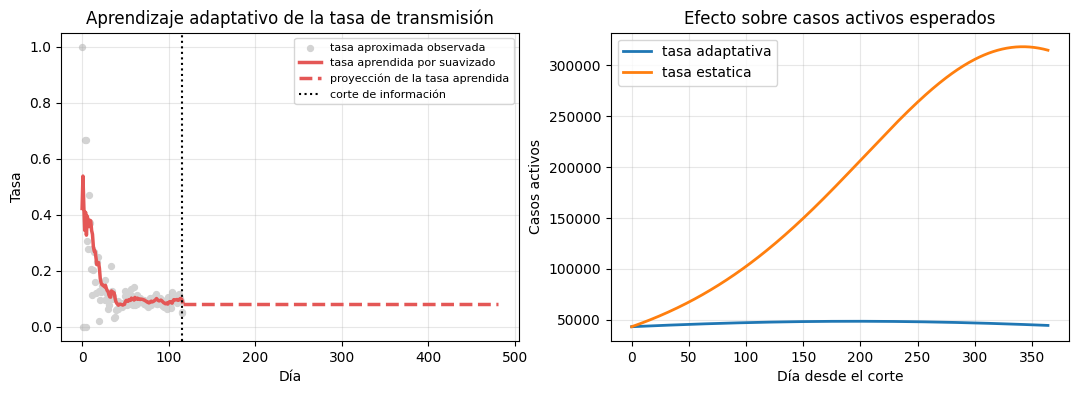

In [5]:
# La comparación entre tasa observada, tasa aprendida y proyección hace visible cómo cada observación actualiza el modelo.

import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
cutoff_day = observed["day"].max()
forecast_day = cutoff_day + 1 + rate_forecast["forecast_day"]

axes[0].scatter(
    observed["day"], observed["infection_rate"],
    color="lightgray", s=18, label="tasa aproximada observada",
)
axes[0].plot(
    observed["day"], observed["smoothed_infection_rate"],
    color="#e45756", linewidth=2.5, label="tasa aprendida por suavizado",
)
axes[0].plot(
    forecast_day, rate_forecast["infection_rate"],
    color="#e45756", linestyle="--", linewidth=2.5, label="proyección de la tasa aprendida",
)
axes[0].axvline(cutoff_day, color="black", linestyle=":", label="corte de información")
axes[0].set(title="Aprendizaje adaptativo de la tasa de transmisión", xlabel="Día", ylabel="Tasa")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

for model, forecast in forecasts.groupby("model"):
    axes[1].plot(forecast["forecast_day"], forecast["infected"], linewidth=2, label=model.replace("_", " "))
axes[1].set(title="Efecto sobre casos activos esperados", xlabel="Día desde el corte", ylabel="Casos activos")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.show()

In [6]:
# Se conservan la tasa proyectada, los pronósticos y la gráfica para verificar el taller.

from pathlib import Path

submission_dir = Path("../submission")
rate_forecast.to_csv(submission_dir / "infection_rate_forecast.csv", index=False)
forecasts.to_csv(submission_dir / "forecasts.csv", index=False)
figure.savefig(submission_dir / "adaptive_evolution.png", dpi=150, bbox_inches="tight")